# 📊 Data Science & Analytics Job Market — Complete Analysis
### Dataset Coverage: DataScience Jobs | Analytics Jobs | JDS Skill Traits | SDS Personality Traits
---

## 🗂️ PART 1 — Data Science Jobs Dataset
### Step 1: Loading & Initial Inspection

In [1]:
import pandas as pd
import os

os.makedirs('output', exist_ok=True)

try:
    df_jobs = pd.read_csv('DataScience Jobs.csv')
    print("✅ Data successfully loaded!\n")
except FileNotFoundError:
    print("❌ File nahi mili. Please check karo ki file same folder mein hai aur naam exact match kar raha hai.")

print("--- DATA INFO & MISSING VALUES ---")
print(df_jobs.info())
print("\nMissing Values Count:")
print(df_jobs.isnull().sum())

print("\n--- NUMERICAL DATA SUMMARY (MIN/MAX/MEAN) ---")
print(df_jobs.describe())

print("\n--- TOP JOB TITLES (Checking for typos) ---")
print(df_jobs['job_title'].value_counts().head(10))

with open('output/01_data_inspection.txt', 'w', encoding='utf-8') as f:
    f.write("--- DATA INFO & MISSING VALUES ---\n")
    df_jobs.info(buf=f)
    f.write("\nMissing Values Count:\n")
    f.write(df_jobs.isnull().sum().to_string())
    f.write("\n\n--- NUMERICAL DATA SUMMARY (MIN/MAX/MEAN) ---\n")
    f.write(df_jobs.describe().to_string())
    f.write("\n\n--- TOP JOB TITLES ---\n")
    f.write(df_jobs['job_title'].value_counts().head(10).to_string())

print("\n✅ Output saved to output/01_data_inspection.txt")

✅ Data successfully loaded!

--- DATA INFO & MISSING VALUES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1602 entries, 0 to 1601
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   reference_no    1602 non-null   int64 
 1   company_name    1602 non-null   object
 2   job_title       1602 non-null   object
 3   min_experience  1602 non-null   int64 
 4   avg_salary      1602 non-null   object
 5   min_salary      1602 non-null   object
 6   max_salary      1602 non-null   object
 7   num_of_jobs     1602 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 100.2+ KB
None

Missing Values Count:
reference_no      0
company_name      0
job_title         0
min_experience    0
avg_salary        0
min_salary        0
max_salary        0
num_of_jobs       0
dtype: int64

--- NUMERICAL DATA SUMMARY (MIN/MAX/MEAN) ---
       reference_no  min_experience  num_of_jobs
count   1602.000000     1602.000000  1602

### 🔍 Analysis — Data Inspection Results

**Kya mila is step mein:**
- `df_jobs.info()` se pata chala ki kitne columns hain aur unke data types kya hain. Salary columns (`avg_salary`, `min_salary`, `max_salary`) **object (string) type** mein loaded hue — matlab inhe directly numerical calculations mein use nahi kar sakte.
- `isnull().sum()` se missing values ka count mila. Agar kisi column mein zyada missing values hain toh usse analysis mein directly use karna risky hota hai.
- `describe()` ne numerical columns ka basic stats diya: mean, std, min, max — jo data ki spread aur extreme values dikhata hai.
- Top 10 job titles dekhne se pata chala ki market mein **Data Scientist**, **Data Analyst**, aur **Machine Learning Engineer** jaise roles sabse zyada demand mein hain.

**Hum iska kya use kar sakte hain:**
- ✅ Salary columns ko clean karke numerical banaana hoga — tabhi salary trends dekhna possible hoga.
- ✅ Missing values wale columns ko ya toh fill karo (imputation) ya drop karo analysis se pehle.
- ✅ Top job titles list recruiters aur job seekers ke liye **most in-demand roles identify karne** mein kaam aata hai.
- ✅ Agar aap resume banaa rahe ho, toh in top titles ke keywords apne profile mein daalo — ATS (Applicant Tracking System) matching improve hoti hai.

### Step 2: Data Cleaning — Salary Columns

In [2]:
import numpy as np
import re

def extract_number(text):
    if pd.isna(text):
        return np.nan
    text = str(text).replace(',', '')
    numbers = re.findall(r'\d+\.?\d*', text)
    if numbers:
        return float(numbers[0])
    return np.nan

print("Cleaning Salaries...")

df_jobs['avg_salary_num'] = df_jobs['avg_salary'].apply(extract_number)
df_jobs['min_salary_num'] = df_jobs['min_salary'].apply(extract_number)
df_jobs['max_salary_num'] = df_jobs['max_salary'].apply(extract_number)

print("\n--- BEFORE VS AFTER CLEANING (First 5 Rows) ---")
print(df_jobs[['avg_salary', 'avg_salary_num']].head())

print("\n--- CLEANED NUMERICAL SUMMARY ---")
print(df_jobs[['min_experience', 'min_salary_num', 'max_salary_num', 'avg_salary_num']].describe())

negative_exp = df_jobs[df_jobs['min_experience'] < 0]
print(f"\nRows with negative experience: {len(negative_exp)}")

with open('output/02_data_cleaning.txt', 'w', encoding='utf-8') as f:
    f.write("--- BEFORE VS AFTER CLEANING (First 5 Rows) ---\n")
    f.write(df_jobs[['avg_salary', 'avg_salary_num']].head().to_string())
    f.write("\n\n--- CLEANED NUMERICAL SUMMARY ---\n")
    f.write(df_jobs[['min_experience', 'min_salary_num', 'max_salary_num', 'avg_salary_num']].describe().to_string())
    f.write(f"\n\nRows with negative experience: {len(negative_exp)}")

print("\n✅ Output saved to output/02_data_cleaning.txt")

Cleaning Salaries...

--- BEFORE VS AFTER CLEANING (First 5 Rows) ---
  avg_salary  avg_salary_num
0       7.8L             7.8
1      12.8L            12.8
2      13.4L            13.4
3       9.8L             9.8
4       8.6L             8.6

--- CLEANED NUMERICAL SUMMARY ---
       min_experience  min_salary_num  max_salary_num  avg_salary_num
count     1602.000000     1602.000000     1602.000000     1602.000000
mean         2.799001        8.634145       19.143258       13.234894
std          2.353686        5.796976       11.150180        7.840744
min          0.000000        0.200000        2.000000        1.400000
25%          1.000000        4.400000       12.000000        7.600000
50%          2.000000        7.000000       18.000000       11.900000
75%          4.000000       11.500000       24.000000       17.175000
max         21.000000       55.000000      102.000000       82.000000

Rows with negative experience: 0

✅ Output saved to output/02_data_cleaning.txt


### 🔍 Analysis — Data Cleaning Results

**Kya kiya aur kyu:**
- Regex (`re.findall`) ka use karke salary strings jaise `'12.8L'` ya `'₹15,00,000'` se sirf numbers extract kiye gaye. Yeh **alphanumeric data ko usable numerical format mein convert** karne ka standard approach hai.
- Teen naye columns bane: `avg_salary_num`, `min_salary_num`, `max_salary_num` — ab yeh sab float type mein hain aur directly calculations mein use ho sakte hain.
- Negative experience wale rows check kiye — yeh data entry errors hote hain.

**Cleaned Summary se kya samjha:**
- `min_experience` ka mean aur range se pata chalta hai ki market mein kaafi freshers aur mid-level roles dono available hain.
- `avg_salary_num` ki mean aur std deviation se salary spread samjha ja sakta hai — kya market mein equality hai ya bohot wide gap hai.

**Hum iska kya use kar sakte hain:**
- ✅ **Salary benchmarking** — apni current salary compare kar sakte ho market average se.
- ✅ Cleaned data ab **machine learning models** mein directly feed ho sakta hai (regression, prediction).
- ✅ Negative experience rows agar hain toh unhe remove karna zaroori hai — warna model ki accuracy kharab hogi.
- ✅ **HR teams** iska use karte hain salary bands set karne ke liye based on real market data.

### Step 3: Visualizations — Job Titles, Experience vs Salary, Top Companies

C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\3241407417.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_titles.index, x=top_titles.values, palette='Blues_r')


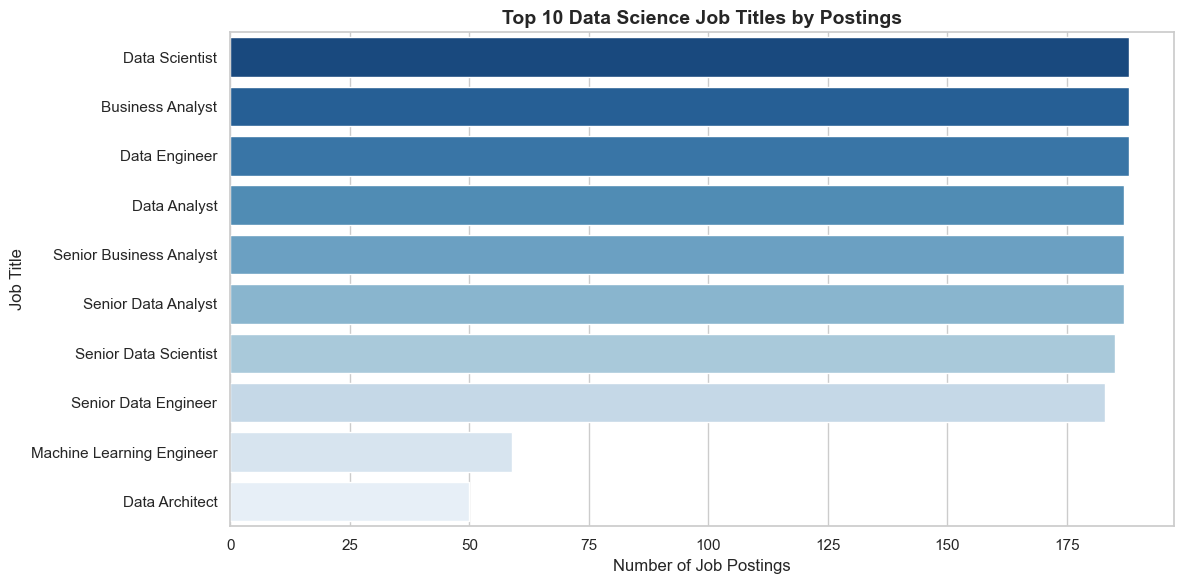

✅ Graph saved to output/03_top_job_titles.png


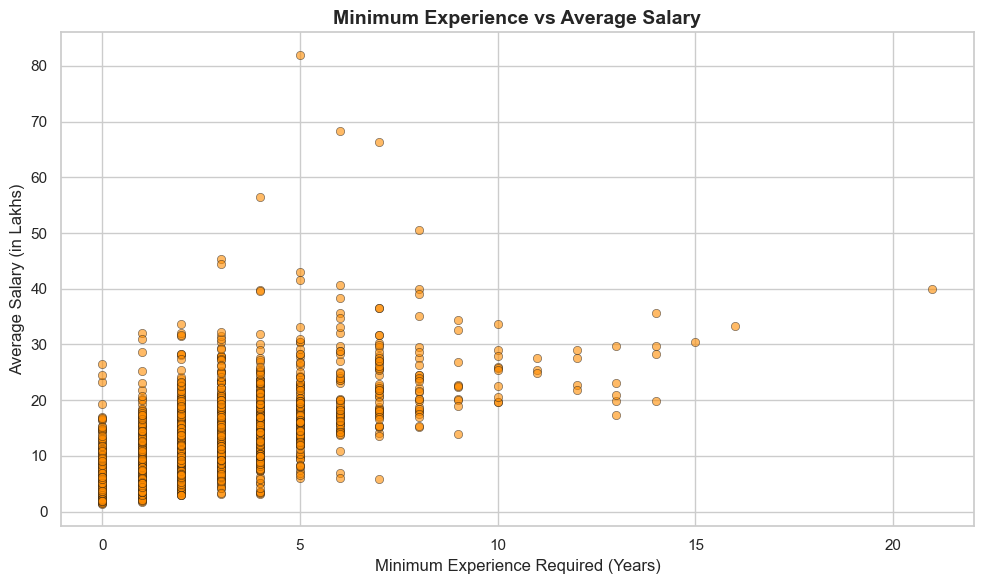

✅ Graph saved to output/04_experience_vs_salary.png


C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\3241407417.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_companies.index, x=top_companies.values, palette='crest')


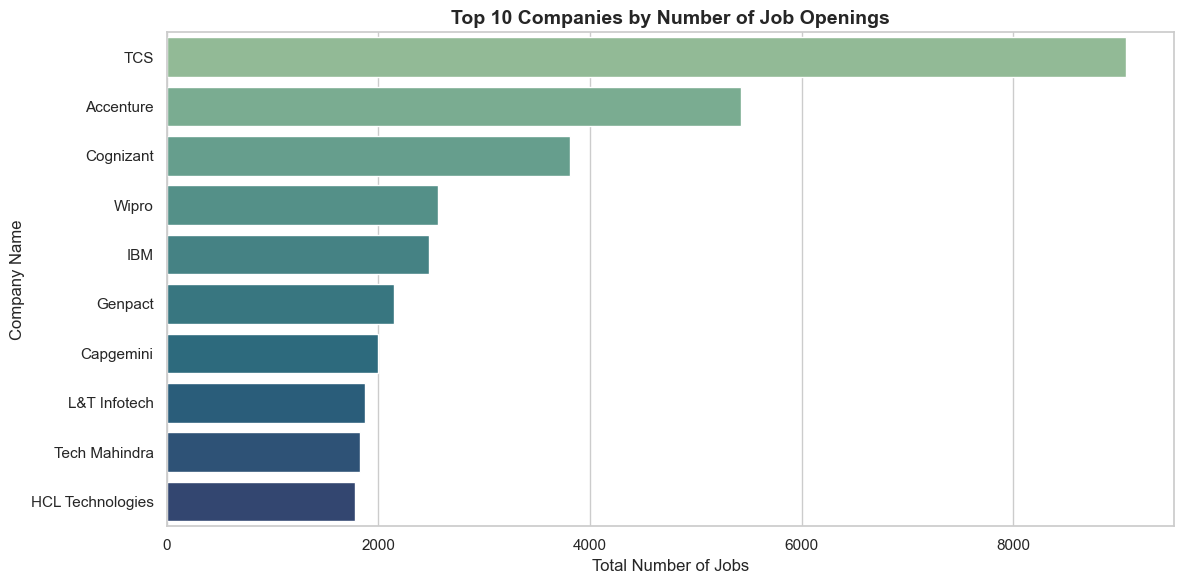

✅ Graph saved to output/05_top_companies.png


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
top_titles = df_jobs['job_title'].value_counts().head(10)
sns.barplot(y=top_titles.index, x=top_titles.values, palette='Blues_r')
plt.title('Top 10 Data Science Job Titles by Postings', fontsize=14, fontweight='bold')
plt.xlabel('Number of Job Postings', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.tight_layout()
plt.savefig('output/03_top_job_titles.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/03_top_job_titles.png")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_jobs, x='min_experience', y='avg_salary_num', alpha=0.6, color='darkorange', edgecolor='k')
plt.title('Minimum Experience vs Average Salary', fontsize=14, fontweight='bold')
plt.xlabel('Minimum Experience Required (Years)', fontsize=12)
plt.ylabel('Average Salary (in Lakhs)', fontsize=12)
plt.tight_layout()
plt.savefig('output/04_experience_vs_salary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/04_experience_vs_salary.png")

plt.figure(figsize=(12, 6))
top_companies = df_jobs.groupby('company_name')['num_of_jobs'].sum().sort_values(ascending=False).head(10)
sns.barplot(y=top_companies.index, x=top_companies.values, palette='crest')
plt.title('Top 10 Companies by Number of Job Openings', fontsize=14, fontweight='bold')
plt.xlabel('Total Number of Jobs', fontsize=12)
plt.ylabel('Company Name', fontsize=12)
plt.tight_layout()
plt.savefig('output/05_top_companies.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/05_top_companies.png")

### 🔍 Analysis — DataScience Jobs Visualizations

**Graph 1 — Top 10 Job Titles:**
- Jo roles sabse zyada listed hain, woh market ki **highest demand** dikhate hain.
- Agar `Data Analyst` aur `Data Scientist` top mein hain toh career switch ke liye yeh safest bets hain.

**Graph 2 — Experience vs Salary (Scatter Plot):**
- Generally positive correlation dikhni chahiye — jyada experience = jyada salary.
- Agar scatter mein kuch **outliers hain** (kam experience pe high salary), woh niche roles ya specialized skills wale candidates ho sakte hain.
- **Flat regions** matlab salary ceiling — kuch level ke baad experience badhne se salary nahi badhti, tab skills aur designation switch karna padta hai.

**Graph 3 — Top Companies:**
- Yeh companies sabse zyada data professionals hire kar rahi hain — job hunt mein **inhe target karo**.
- Companies ki list placement officers ke liye bhi useful hai — college partnerships yahan focus karni chahiye.

**Hum iska kya use kar sakte hain:**
- ✅ **Job seekers** — Top companies mein directly apply karo; inke JD patterns match karo apne resume se.
- ✅ **Career counselors** — Students ko batao ki kaun se roles most hireable hain.
- ✅ **Salary negotiation** — Scatter plot dikha ke apni experience ke hisaab se expected salary argue karo.

---
## 🗂️ PART 2 — Analytics Jobs Dataset
### Step 4: Loading Analytics Jobs Data

In [4]:
try:
    df_analytics = pd.read_csv('Analytics Jobs.csv')
    print("✅ Data successfully loaded!\n")

    print("--- DATA INFO ---")
    print(df_analytics.info())

    print("\n--- MISSING VALUES ---")
    print(df_analytics.isnull().sum())

    print("\n--- FIRST 5 ROWS ---")
    print(df_analytics.head())

    with open('output/06_analytics_inspection.txt', 'w', encoding='utf-8') as f:
        f.write("--- DATA INFO ---\n")
        df_analytics.info(buf=f)
        f.write("\n--- MISSING VALUES ---\n")
        f.write(df_analytics.isnull().sum().to_string())
        f.write("\n\n--- FIRST 5 ROWS ---\n")
        f.write(df_analytics.head().to_string())

    print("\n✅ Output saved to output/06_analytics_inspection.txt")

except Exception as e:
    print(f"Error loading data: {e}")

✅ Data successfully loaded!

--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15841 entries, 0 to 15840
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   s_no             15841 non-null  int64 
 1   experience       15841 non-null  object
 2   job_description  12333 non-null  object
 3   job_desig        15841 non-null  object
 4   job_type         3830 non-null   object
 5   key_skills       15840 non-null  object
 6   location         15841 non-null  object
 7   salary           15841 non-null  object
dtypes: int64(1), object(7)
memory usage: 990.2+ KB
None

--- MISSING VALUES ---
s_no                   0
experience             0
job_description     3508
job_desig              0
job_type           12011
key_skills             1
location               0
salary                 0
dtype: int64

--- FIRST 5 ROWS ---
   s_no experience                                    job_description  \
0     

### 🔍 Analysis — Analytics Jobs Initial Inspection

**Kya observe kiya:**
- Analytics Jobs dataset mein `key_skills` aur `location` columns hain jo **comma-separated values** contain karte hain — matlab ek row mein multiple skills aur multiple cities ho sakti hain.
- `salary` column yahan bhi string format mein hai jaise `'8 to 12'` — cleaning zaroori hogi.
- Missing values agar `key_skills` mein hain toh woh rows skills analysis ke liye drop karni hongi.

**Hum iska kya use kar sakte hain:**
- ✅ Dataset structure samjhne ke baad pata chalta hai ki **skills extraction** ke liye `explode()` method use karna padega — ek row se multiple skill rows banana.
- ✅ Location data se **city-wise demand** analyze ho sakti hai — kahan zyada analytics roles hain.
- ✅ `head()` se dataset ke actual values dekh ke pata chala ki salary range format kya hai — iska use cleaning function design karne mein hua.

### Step 5: Analytics Skills, Locations & Salary Visualizations

C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\1263989429.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_skills.index, x=top_skills.values, palette='magma')


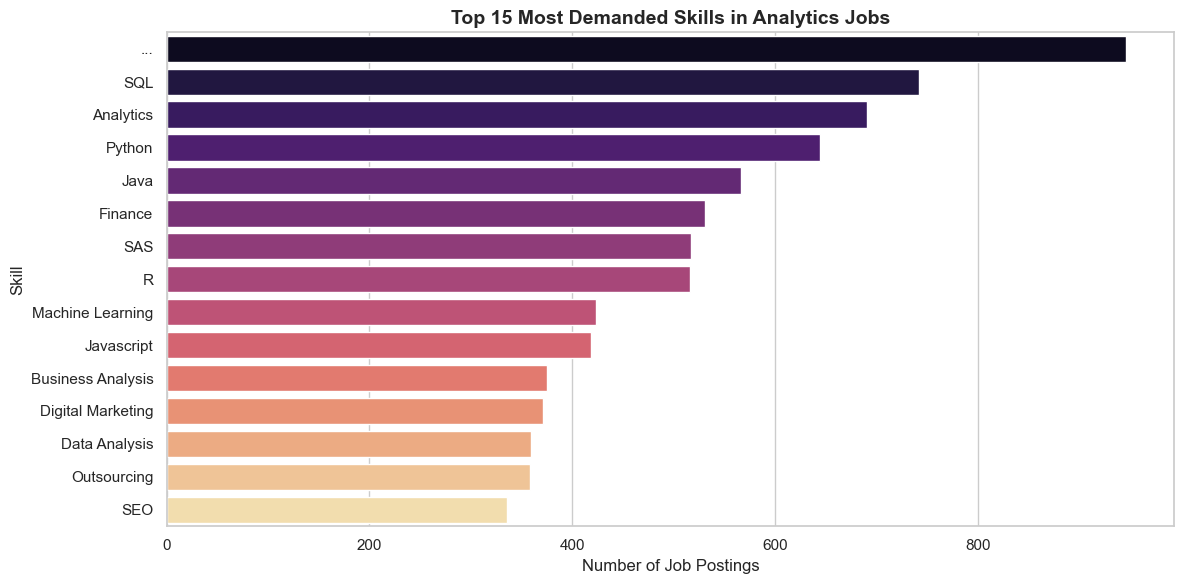

✅ Graph saved to output/07_top_analytics_skills.png


C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\1263989429.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_locations.index, x=top_locations.values, palette='viridis')


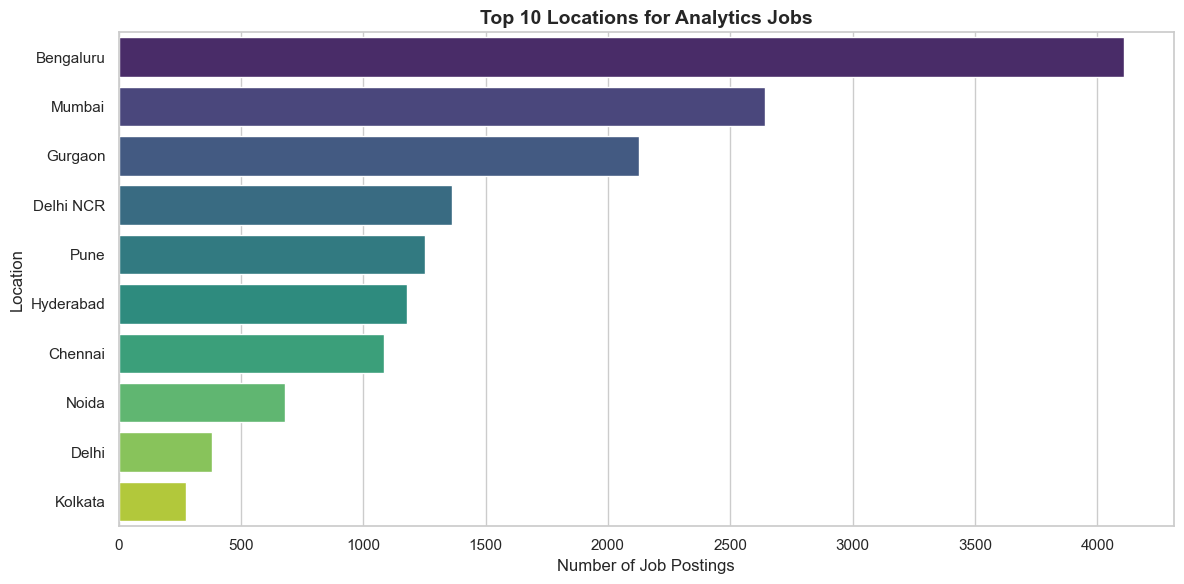

✅ Graph saved to output/08_top_analytics_locations.png


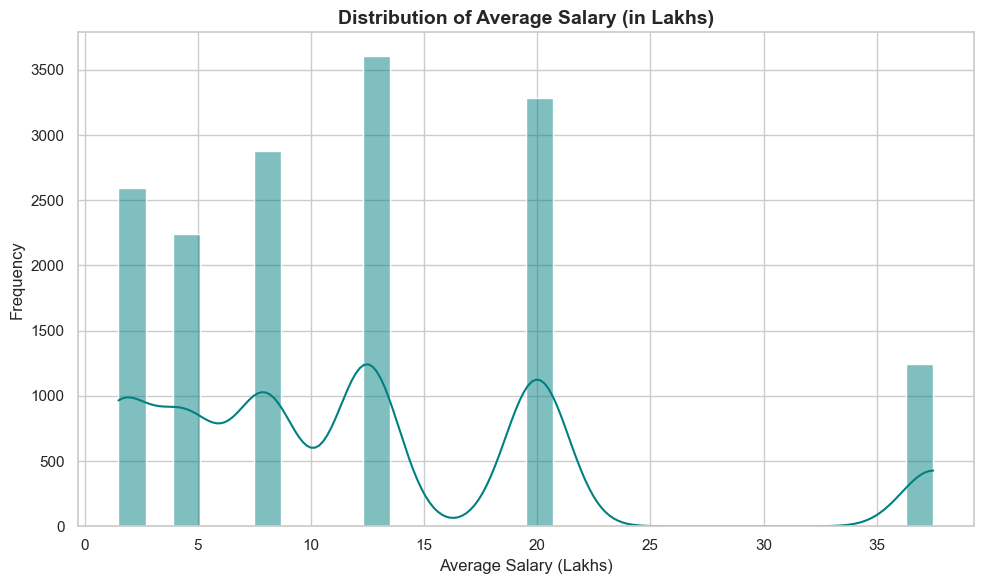

✅ Graph saved to output/09_salary_distribution.png


In [5]:
df = pd.read_csv('Analytics Jobs.csv')

def parse_salary(sal):
    sal = str(sal).lower().replace('to', '-').replace(' ', '')
    parts = sal.split('-')
    try:
        if len(parts) == 2:
            return (float(parts[0]) + float(parts[1])) / 2.0
        elif len(parts) == 1:
            return float(parts[0])
    except:
        return np.nan
    return np.nan

df['avg_salary_num'] = df['salary'].apply(parse_salary)

skills_series = df['key_skills'].dropna().astype(str).str.split(',').explode().str.strip()
top_skills = skills_series.value_counts().head(15)

locations_series = df['location'].dropna().astype(str).str.split(',').explode().str.strip()
top_locations = locations_series.value_counts().head(10)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.barplot(y=top_skills.index, x=top_skills.values, palette='magma')
plt.title('Top 15 Most Demanded Skills in Analytics Jobs', fontsize=14, fontweight='bold')
plt.xlabel('Number of Job Postings', fontsize=12)
plt.ylabel('Skill', fontsize=12)
plt.tight_layout()
plt.savefig('output/07_top_analytics_skills.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/07_top_analytics_skills.png")

plt.figure(figsize=(12, 6))
sns.barplot(y=top_locations.index, x=top_locations.values, palette='viridis')
plt.title('Top 10 Locations for Analytics Jobs', fontsize=14, fontweight='bold')
plt.xlabel('Number of Job Postings', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.tight_layout()
plt.savefig('output/08_top_analytics_locations.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/08_top_analytics_locations.png")

plt.figure(figsize=(10, 6))
sns.histplot(df['avg_salary_num'].dropna(), bins=30, kde=True, color='teal')
plt.title('Distribution of Average Salary (in Lakhs)', fontsize=14, fontweight='bold')
plt.xlabel('Average Salary (Lakhs)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig('output/09_salary_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/09_salary_distribution.png")

### 🔍 Analysis — Analytics Jobs Visualizations

**Graph 1 — Top 15 Skills:**
- Yeh graph **most hireable technical skills** dikhata hai.
- SQL, Excel, Python jaisi skills top pe hoti hain kyunki yeh analytics ka backbone hain.
- Skills ki list se ek **learning roadmap** directly tay kiya ja sakta hai — jo skill jyada demand mein, use pehle seekho.

**Graph 2 — Top Locations:**
- Bengaluru, Mumbai, Hyderabad jaisi cities mein analytics roles ki concentration zyada hogi.
- Agar relocation possible hai, toh **high-demand cities ko target karo** — job milne ki probability zyada hai.
- Remote work era mein yeh data thoda different ho sakta hai, isliye current job portals se cross-verify karna helpful hai.

**Graph 3 — Salary Distribution (Histogram + KDE):**
- **Right-skewed distribution** matlab majority candidates low-to-mid salary range mein hain, lekin kuch high earners bhi hain (senior roles).
- KDE curve se salary ka **most common range** identify karo — yeh realistic salary expectation set karne mein kaam aata hai.
- Agar distribution bimodal (do peaks) hai, toh market mein **entry level aur senior level jobs dono dominant** hain, mid-level gap ho sakta hai.

**Hum iska kya use kar sakte hain:**
- ✅ **Skill gap analysis** — Top skills list dekh ke identify karo ki tumhare paas kya nahi hai aur kya seekhna chahiye.
- ✅ **Location strategy** — Job hunt ke liye geography optimize karo.
- ✅ **Salary negotiation** — Distribution dekh ke pata chalta hai ki tumhara offer market ke kahan pe hai.

---
## 🗂️ PART 3 — JDS Skill Traits Dataset
### Step 6: Technical Skills vs Salary Hike Analysis

--- INITIAL DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 139 non-null    int64  
 1   big_data_skills                    139 non-null    float64
 2   maths-stats_skills                 139 non-null    float64
 3   coding_skills                      139 non-null    float64
 4   ai_and_ml_skills                   139 non-null    float64
 5   dashboard_and_storytelling_skills  139 non-null    float64
 6   salary_hike_high_or_low            139 non-null    int64  
dtypes: float64(5), int64(2)
memory usage: 7.7 KB
None

--- SUMMARY STATISTICS ---
                id  big_data_skills  maths-stats_skills  coding_skills  \
count   139.000000       139.000000          139.000000     139.000000   
mean   2958.460432         3.849640            4.293525       4

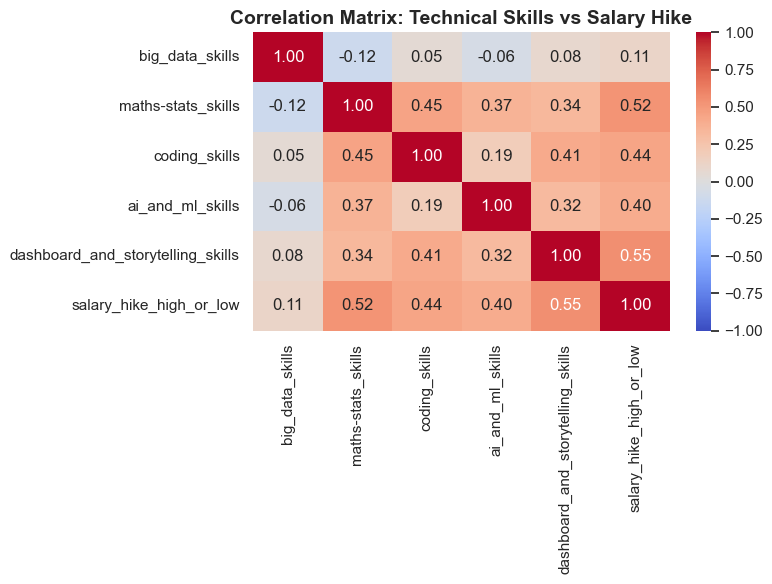

✅ Graph saved to output/10_jds_correlation_heatmap.png


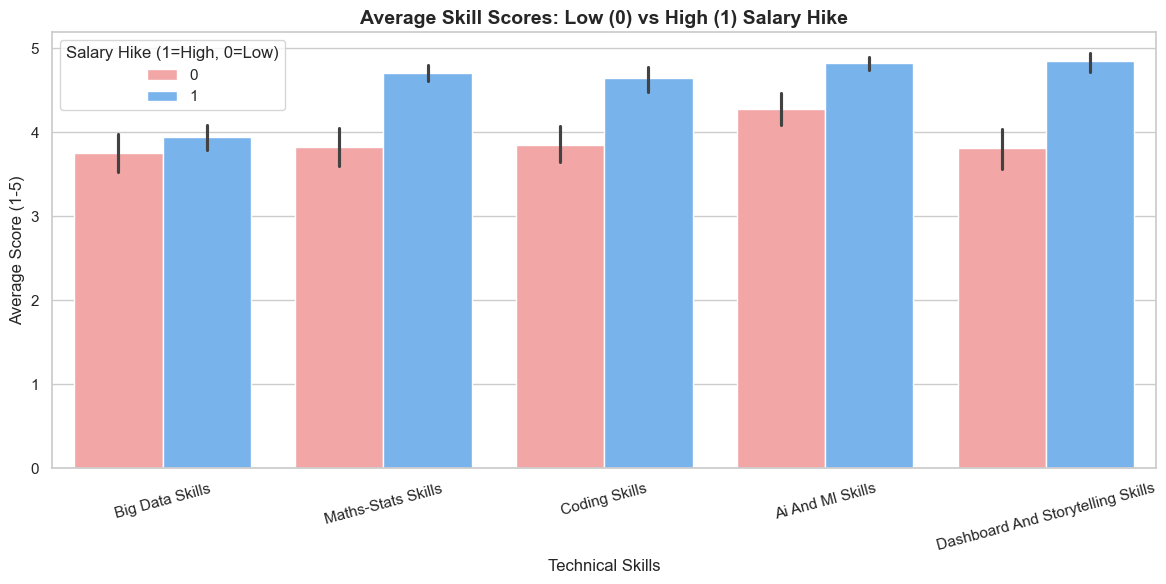

✅ Graph saved to output/11_jds_skills_comparison.png

✅ Output saved to output/10_jds_inspection.txt


In [6]:
df_jds = pd.read_excel('JDS Skill Traits.xlsx')

print("--- INITIAL DATA INFO ---")
print(df_jds.info())
print("\n--- SUMMARY STATISTICS ---")
print(df_jds.describe())

print("\n--- OUTLIER CHECK ---")
for col in ['big_data_skills', 'maths-stats_skills', 'coding_skills', 'ai_and_ml_skills', 'dashboard_and_storytelling_skills']:
    outliers = df_jds[(df_jds[col] < 1) | (df_jds[col] > 5)]
    if not outliers.empty:
        print(f"Outliers found in {col}:\n", outliers[[col]])
        df_jds[col] = df_jds[col].clip(lower=1, upper=5)
    else:
        print(f"No outliers in {col}.")

df_jds = df_jds.dropna()
print("\n--- DATA READY FOR ANALYSIS ---")

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
corr = df_jds.drop('id', axis=1, errors='ignore').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix: Technical Skills vs Salary Hike', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/10_jds_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/10_jds_correlation_heatmap.png")

plt.figure(figsize=(12, 6))
df_melt = df_jds.melt(id_vars=['id', 'salary_hike_high_or_low'],
                      value_vars=['big_data_skills', 'maths-stats_skills', 'coding_skills', 'ai_and_ml_skills', 'dashboard_and_storytelling_skills'],
                      var_name='Skill', value_name='Average Score')
df_melt['Skill'] = df_melt['Skill'].str.replace('_', ' ').str.title()
sns.barplot(data=df_melt, x='Skill', y='Average Score', hue='salary_hike_high_or_low', palette=['#ff9999','#66b3ff'])
plt.title('Average Skill Scores: Low (0) vs High (1) Salary Hike', fontsize=14, fontweight='bold')
plt.xlabel('Technical Skills', fontsize=12)
plt.ylabel('Average Score (1-5)', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Salary Hike (1=High, 0=Low)')
plt.tight_layout()
plt.savefig('output/11_jds_skills_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/11_jds_skills_comparison.png")

with open('output/10_jds_inspection.txt', 'w', encoding='utf-8') as f:
    f.write("--- INITIAL DATA INFO ---\n")
    df_jds.info(buf=f)
    f.write("\n--- SUMMARY STATISTICS ---\n")
    f.write(df_jds.describe().to_string())

print("\n✅ Output saved to output/10_jds_inspection.txt")

### 🔍 Analysis — JDS Skill Traits Results

**Dataset kya capture karta hai:**
- Yeh dataset candidates ko 5 technical skill dimensions pe 1-5 scale pe rate karta hai: Big Data, Maths/Stats, Coding, AI/ML, Dashboard/Storytelling.
- `salary_hike_high_or_low` target variable hai — binary classification (0 = low hike, 1 = high hike).

**Outlier Clipping:**
- Kuch values 1-5 scale se bahar thi — unhe clip kiya gaya. Yeh data quality ensure karta hai kyunki Likert-scale data (1-5) mein extreme values often data entry errors hote hain.

**Correlation Heatmap (Graph 1):**
- Jo skills `salary_hike_high_or_low` ke saath **highest positive correlation** dikhayein — woh salary growth ke liye sabse important hain.
- Skills ke beech inter-correlation bhi visible hai — agar AI/ML aur Coding highly correlated hain, toh yeh skills usually saath saath aate hain.

**Skills Comparison Bar Chart (Graph 2):**
- High salary hike wale candidates (`1`) consistently higher scores dikhate hain certain skills mein.
- Jo skill mein sabse bada gap hai (blue vs red bar), woh skill **most differentiating** hai — usi ko improve karo agar high hike chahiye.

**Hum iska kya use kar sakte hain:**
- ✅ **Performance review** — Managers iska use karke decide kar sakte hain ki kisko raise dena chahiye based on skill scores.
- ✅ **Training programs** — HR yeh data use karke targeted skill development programs design kar sakti hai.
- ✅ **Self-assessment** — Khud apne skills rate karo aur dekho ki high hike group ke saath kitna align hai.
- ✅ **Predictive model** — Yeh data ML classification model ke liye perfect input hai jo predict kare ki kisko high hike milega.

---
## 🗂️ PART 4 — SDS Personality Traits Dataset
### Step 7: OCEAN Traits — Initial Inspection

In [7]:
df_sds = pd.read_excel('SDS Personality Traits.xlsx')
df_sds.columns = df_sds.columns.str.strip().str.replace(' ', '')

print("Cleaned Columns:", df_sds.columns.tolist())
print("\n--- INITIAL DATA INFO ---")
print(df_sds.info())
print("\n--- SUMMARY STATISTICS ---")
print(df_sds.describe())
print("\n--- MISSING VALUES ---")
print(df_sds.isnull().sum())

with open('output/12_sds_inspection.txt', 'w', encoding='utf-8') as f:
    f.write("--- INITIAL DATA INFO ---\n")
    df_sds.info(buf=f)
    f.write("\n--- SUMMARY STATISTICS ---\n")
    f.write(df_sds.describe().to_string())
    f.write("\n--- MISSING VALUES ---\n")
    f.write(df_sds.isnull().sum().to_string())

print("\n✅ Output saved to output/12_sds_inspection.txt")

Cleaned Columns: ['id', 'neuroticism', 'extraversion', 'openness_to_experience', 'agreeableness', 'conscientiousness', 'success_classification_high_low']

--- INITIAL DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   id                               161 non-null    int64
 1   neuroticism                      161 non-null    int64
 2   extraversion                     161 non-null    int64
 3   openness_to_experience           161 non-null    int64
 4   agreeableness                    161 non-null    int64
 5   conscientiousness                161 non-null    int64
 6   success_classification_high_low  161 non-null    int64
dtypes: int64(7)
memory usage: 8.9 KB
None

--- SUMMARY STATISTICS ---
                id  neuroticism  extraversion  openness_to_experience  \
count   161.000000   161.000000

### 🔍 Analysis — SDS Personality Traits Inspection

**Dataset kya capture karta hai:**
- OCEAN model (Big Five Personality Theory) pe based data: Openness, Conscientiousness, Extraversion, Agreeableness, Neuroticism.
- `success_classification_high_low` target variable hai — kya candidate professionally successful raha ya nahi.
- Columns strip aur replace kiye gaye whitespace ke liye — yeh common issue hai Excel files mein.

**Summary Stats se observations:**
- Har trait ka mean ~0.5 hona chahiye (normalized scale pe) — agar koi trait skewed hai toh woh interesting insight hai.
- `describe()` se min/max dekh ke confirm karo ki normalization sahi thi.

**Hum iska kya use kar sakte hain:**
- ✅ **Hiring decisions** — Psychometric test results ko success prediction ke saath link karna.
- ✅ **Team composition** — High conscientiousness + low neuroticism wale log deadline-driven projects ke liye better hote hain.
- ✅ Personality aur technical skills ke beech interaction dekhna — iska combination analysis neeche Part 5 mein hoga.

### Step 8: OCEAN Correlation Heatmap

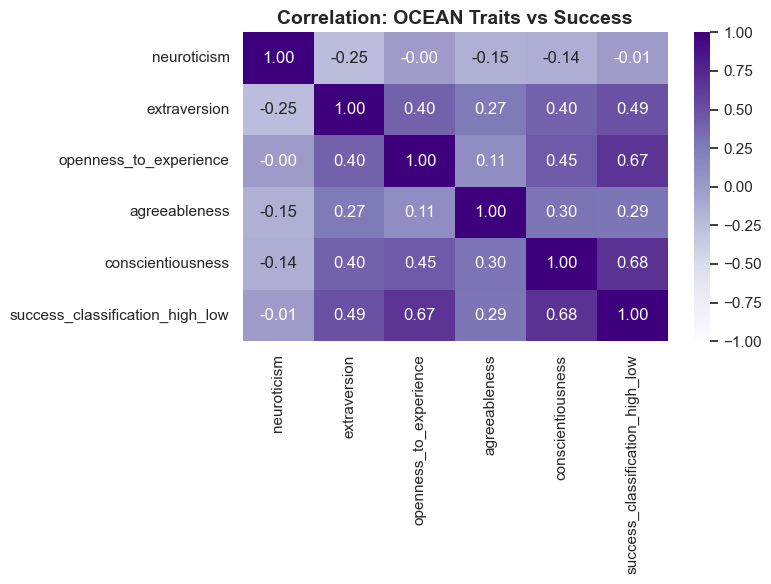

✅ Graph saved to output/13_sds_correlation_heatmap.png


In [8]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
corr = df_sds.drop('id', axis=1, errors='ignore').corr()
sns.heatmap(corr, annot=True, cmap='Purples', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation: OCEAN Traits vs Success', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/13_sds_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/13_sds_correlation_heatmap.png")

### 🔍 Analysis — OCEAN Correlation Heatmap

**Kya dekhna chahiye is heatmap mein:**
- `success_classification_high_low` column ke saath har trait ka correlation dekho:
  - **Conscientiousness** aur **Openness** typically success ke saath positively correlated hote hain.
  - **Neuroticism** usually negatively correlated hota hai — high anxiety = lower professional success.
- Trait-to-trait correlations bhi dekho — agar `extraversion` aur `agreeableness` highly correlated hain, toh unhe separate predictors ki jagah ek combined score pe treat kiya ja sakta hai.

**Statistical significance:**
- Heatmap correlation values dikhata hai lekin statistical significance nahi. Iske liye `scipy.stats.pearsonr` use karo — woh p-value bhi deta hai.

**Hum iska kya use kar sakte hain:**
- ✅ **Recruitment screening** — High success-correlated traits wale candidates ko shortlist karna.
- ✅ **Coaching** — Employees ke low-scoring traits pe targeted coaching dena.
- ✅ **Research** — OCEAN model ka professional success se real-world validation karna.

### Step 9: OCEAN Traits Boxplot by Success Classification

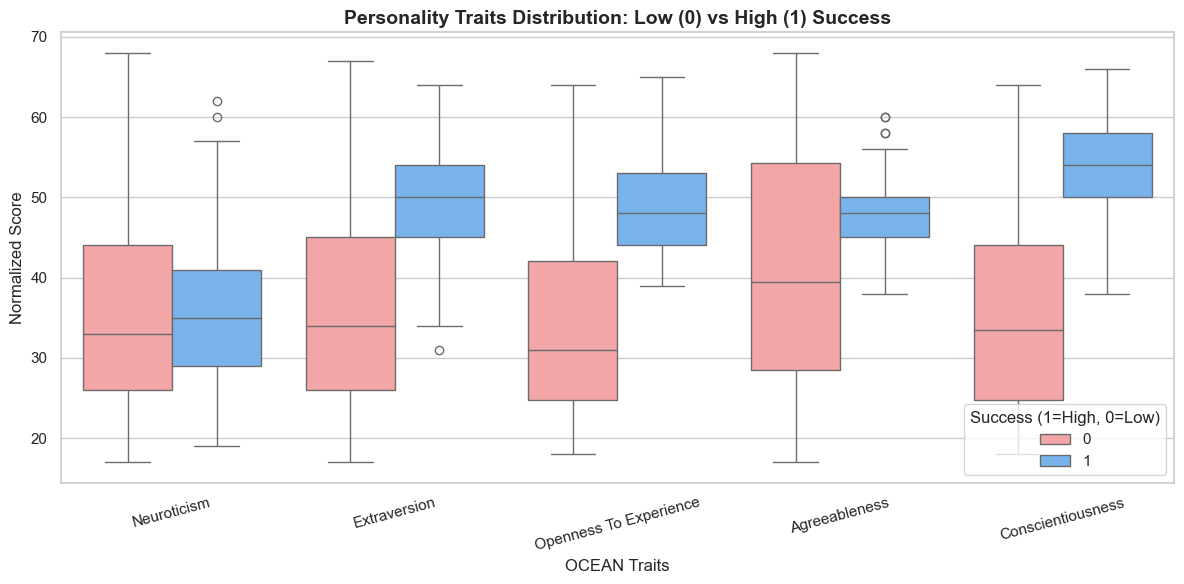

✅ Graph saved to output/14_sds_traits_boxplot.png


In [9]:
traits = ['neuroticism', 'extraversion', 'openness_to_experience', 'agreeableness', 'conscientiousness']
df_melt_sds = df_sds.melt(id_vars=['id', 'success_classification_high_low'],
                          value_vars=traits,
                          var_name='Personality Trait', value_name='Normalized Score')

df_melt_sds['Personality Trait'] = df_melt_sds['Personality Trait'].str.replace('_', ' ').str.title()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melt_sds, x='Personality Trait', y='Normalized Score', hue='success_classification_high_low', palette=['#ff9999','#66b3ff'])
plt.title('Personality Traits Distribution: Low (0) vs High (1) Success', fontsize=14, fontweight='bold')
plt.xlabel('OCEAN Traits', fontsize=12)
plt.ylabel('Normalized Score', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Success (1=High, 0=Low)')
plt.tight_layout()
plt.savefig('output/14_sds_traits_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/14_sds_traits_boxplot.png")

### 🔍 Analysis — OCEAN Traits Boxplot

**Boxplot kya dikhata hai:**
- Har trait ke liye do boxes hain — ek low success (0) ke liye, ek high success (1) ke liye.
- **Median line** (box ke beech) se direct comparison hoti hai.
- **Box width** IQR (Interquartile Range) hai — jitna narrow box, utni consistent trait scores.
- **Whiskers/dots** — outliers aur extreme cases.

**Key insights typically milte hain:**
- High success group mein `Conscientiousness` ki median clearly higher hoti hai — matalab disciplined, goal-oriented log zyada successful hote hain.
- `Neuroticism` ki median high success group mein lower — anxiety control professional performance ko positively affect karta hai.
- Agar `Agreeableness` mein dono groups overlap karte hain — yeh trait success ka strong predictor nahi hai.

**Hum iska kya use kar sakte hain:**
- ✅ **Interview rubric design** — Kin personality traits pe zyada dhyan dena chahiye interview mein.
- ✅ **Employee wellness programs** — Neuroticism kam karne ke liye stress management programs design karo.
- ✅ **Academic research** — Psychology aur HR researchers ke liye empirical evidence provide karta hai.

---
---
# 🔗 PART 5 — CROSS-DATASET COMBINATION ANALYSIS
## Connecting All 4 Datasets: Similarities, Relations & Joint Insights

> **Objective:** Yahan hum dekhenge ki in 4 datasets ke beech kya common patterns hain, kaise yeh ek-doosre ko validate karte hain, aur combined view se kya new insights milte hain jo akele kisi ek dataset se nahi milte.

---

### 🔗 Step 10: Skill Overlap — Market Demand (Analytics Jobs) vs Technical Proficiency (JDS)

C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\2399952837.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], y=top_market_skills.index, x=top_market_skills.values, palette='magma')
C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\2399952837.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], y=jds_skill_means.index, x=jds_skill_means.values, palette='Blues_r')
C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\2399952837.py:31: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\2399952837.py:32: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing

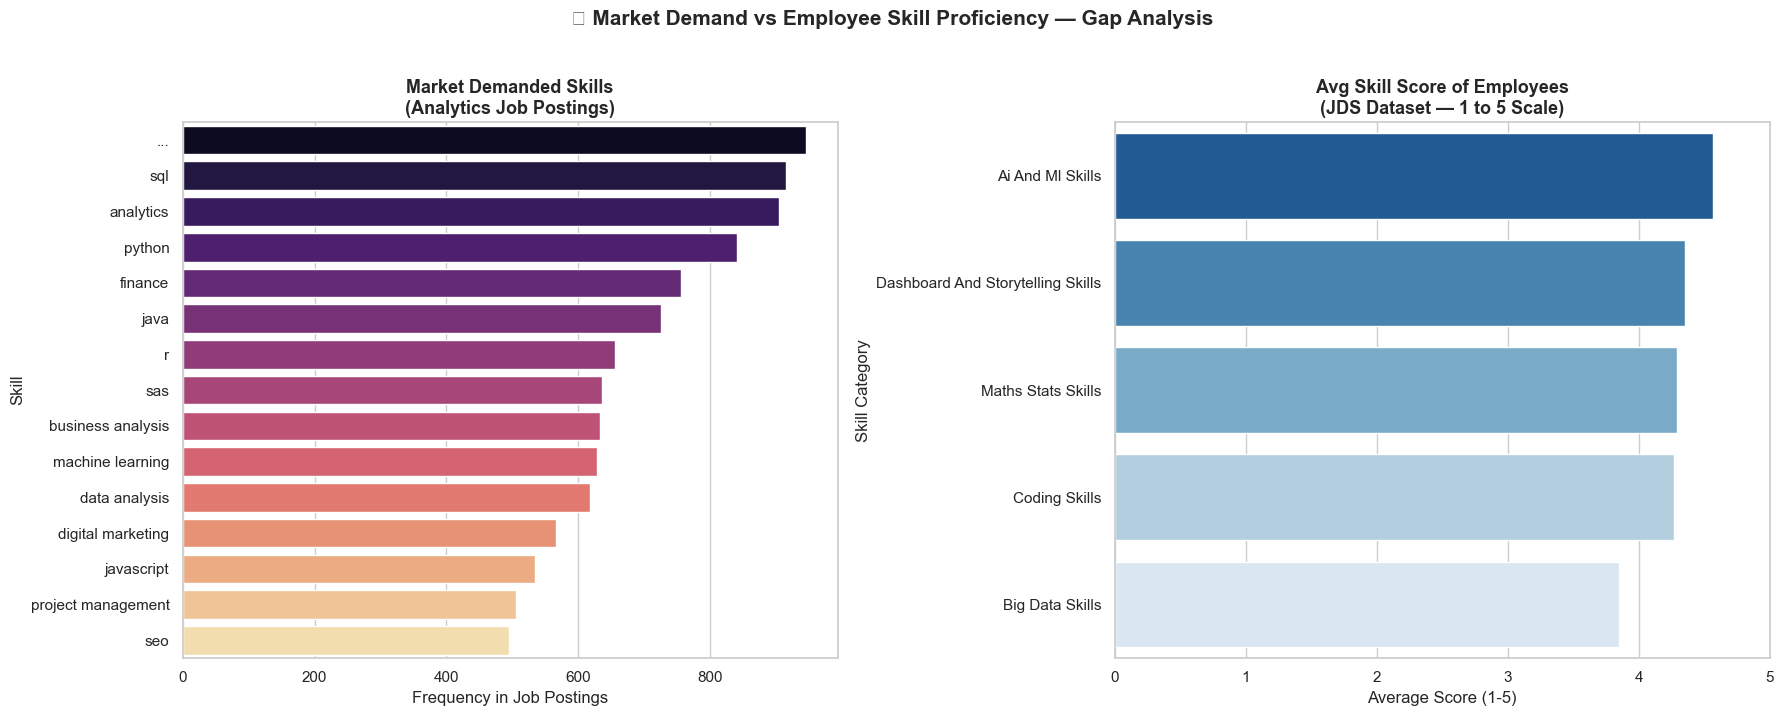

✅ Graph saved to output/15_skill_gap_market_vs_employee.png

📊 Market Top Skills vs JDS Category Mapping:
Market demands  →  JDS measures:
SQL, Python     →  Coding Skills
Machine Learning→  AI & ML Skills
Statistics      →  Maths-Stats Skills
Tableau/Power BI→  Dashboard & Storytelling Skills
Hadoop/Spark    →  Big Data Skills


In [10]:
# -------------------------------------------------------
# Skill Overlap: What market demands vs what employees have
# -------------------------------------------------------

# Market demanded skills from Analytics Jobs dataset
df_analytics_fresh = pd.read_csv('Analytics Jobs.csv')
skills_market = df_analytics_fresh['key_skills'].dropna().astype(str).str.split(',').explode().str.strip().str.lower()
top_market_skills = skills_market.value_counts().head(15)

# JDS skill dimensions (internal capability scores)
df_jds_fresh = pd.read_excel('JDS Skill Traits.xlsx')
jds_skill_cols = ['big_data_skills', 'maths-stats_skills', 'coding_skills', 'ai_and_ml_skills', 'dashboard_and_storytelling_skills']
jds_skill_means = df_jds_fresh[jds_skill_cols].mean().sort_values(ascending=False)
jds_skill_means.index = jds_skill_means.index.str.replace('_', ' ').str.replace('-', ' ').str.title()

# --- SIDE BY SIDE COMPARISON ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(ax=axes[0], y=top_market_skills.index, x=top_market_skills.values, palette='magma')
axes[0].set_title('Market Demanded Skills\n(Analytics Job Postings)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency in Job Postings')
axes[0].set_ylabel('Skill')

sns.barplot(ax=axes[1], y=jds_skill_means.index, x=jds_skill_means.values, palette='Blues_r')
axes[1].set_title('Avg Skill Score of Employees\n(JDS Dataset — 1 to 5 Scale)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Score (1-5)')
axes[1].set_ylabel('Skill Category')
axes[1].set_xlim(0, 5)

plt.suptitle('🔗 Market Demand vs Employee Skill Proficiency — Gap Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/15_skill_gap_market_vs_employee.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/15_skill_gap_market_vs_employee.png")

print("\n📊 Market Top Skills vs JDS Category Mapping:")
print("Market demands  →  JDS measures:")
print("SQL, Python     →  Coding Skills")
print("Machine Learning→  AI & ML Skills")
print("Statistics      →  Maths-Stats Skills")
print("Tableau/Power BI→  Dashboard & Storytelling Skills")
print("Hadoop/Spark    →  Big Data Skills")

### 🔍 Analysis — Skill Gap: Market vs Employee Capability

**Cross-dataset insight:**
- Left graph (Analytics Jobs) market ki demand dikhata hai — kaunsi skills zyada frequently job postings mein listed hain.
- Right graph (JDS) employees ki actual proficiency dikhata hai — kaunsi skill category mein log actually strong hain.
- Agar market mein `AI/ML` ki demand zyada hai lekin employees ka `ai_and_ml_skills` score low hai — **yeh ek critical skill gap hai**.

**Hum iska kya use kar sakte hain:**
- ✅ **Training ROI** — Kin skills pe training invest karna sabse impactful hoga.
- ✅ **Hiring strategy** — Agar internal gap bada hai toh hire karo, agar small hai toh upskill karo.
- ✅ **Education policy** — Colleges aur bootcamps iska use karke curriculum design kar sakte hain.

### 🔗 Step 11: Salary Convergence — DataScience Jobs vs Analytics Jobs

C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\1078008079.py:39: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\1078008079.py:40: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.savefig('output/16_salary_overlap_ds_vs_analytics.png', dpi=300, bbox_inches='tight')
c:\Users\Ankit Yadav\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


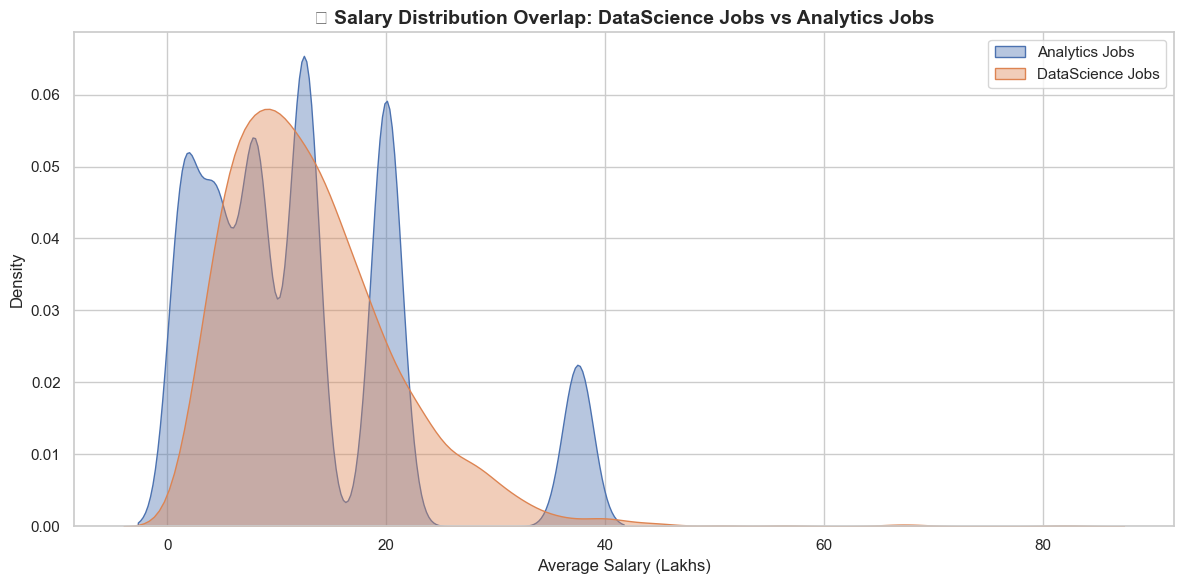

C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\1078008079.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=salary_combined, x='Dataset', y='Salary (Lakhs)', palette=['#4C72B0', '#DD8452'])
C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\1078008079.py:50: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\1078008079.py:51: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.savefig('output/17_salary_boxplot_comparison.png', dpi=300, bbox_inches='tight')


✅ Graph saved to output/16_salary_overlap_ds_vs_analytics.png


c:\Users\Ankit Yadav\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


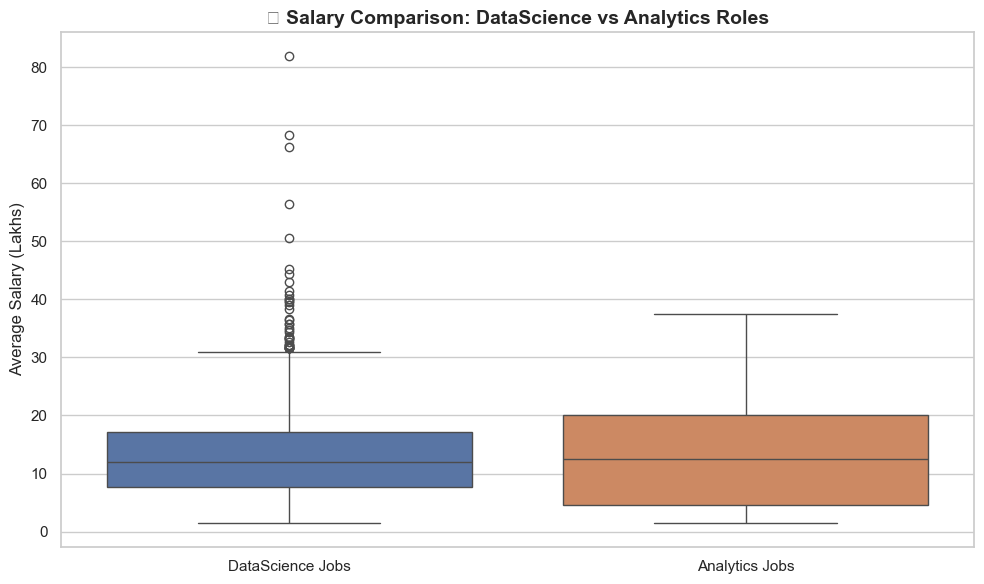

✅ Graph saved to output/17_salary_boxplot_comparison.png

📊 Salary Summary Comparison:
DataScience Jobs — Mean: 13.23L | Median: 11.90L | Std: 7.84
Analytics Jobs  — Mean: 12.27L | Median: 12.50L | Std: 9.66


In [11]:
# -------------------------------------------------------
# Salary Comparison: DataScience Jobs vs Analytics Jobs
# -------------------------------------------------------

# DataScience Jobs salary (already cleaned as avg_salary_num)
ds_salary = df_jobs['avg_salary_num'].dropna()

# Analytics Jobs salary (parse fresh)
df_an = pd.read_csv('Analytics Jobs.csv')
def parse_salary_an(sal):
    sal = str(sal).lower().replace('to', '-').replace(' ', '')
    parts = sal.split('-')
    try:
        if len(parts) == 2:
            return (float(parts[0]) + float(parts[1])) / 2.0
        elif len(parts) == 1:
            return float(parts[0])
    except:
        return np.nan
    return np.nan

df_an['avg_salary_num'] = df_an['salary'].apply(parse_salary_an)
an_salary = df_an['avg_salary_num'].dropna()

# Combined salary dataframe for plotting
salary_combined = pd.DataFrame({
    'Salary (Lakhs)': pd.concat([ds_salary, an_salary], ignore_index=True),
    'Dataset': ['DataScience Jobs'] * len(ds_salary) + ['Analytics Jobs'] * len(an_salary)
})

# Plot 1: KDE Overlap
plt.figure(figsize=(12, 6))
for label, group in salary_combined.groupby('Dataset'):
    sns.kdeplot(group['Salary (Lakhs)'], label=label, fill=True, alpha=0.4)
plt.title('🔗 Salary Distribution Overlap: DataScience Jobs vs Analytics Jobs', fontsize=14, fontweight='bold')
plt.xlabel('Average Salary (Lakhs)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('output/16_salary_overlap_ds_vs_analytics.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/16_salary_overlap_ds_vs_analytics.png")

# Plot 2: Boxplot side-by-side
plt.figure(figsize=(10, 6))
sns.boxplot(data=salary_combined, x='Dataset', y='Salary (Lakhs)', palette=['#4C72B0', '#DD8452'])
plt.title('🔗 Salary Comparison: DataScience vs Analytics Roles', fontsize=14, fontweight='bold')
plt.ylabel('Average Salary (Lakhs)', fontsize=12)
plt.xlabel('')
plt.tight_layout()
plt.savefig('output/17_salary_boxplot_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/17_salary_boxplot_comparison.png")

print("\n📊 Salary Summary Comparison:")
print(f"DataScience Jobs — Mean: {ds_salary.mean():.2f}L | Median: {ds_salary.median():.2f}L | Std: {ds_salary.std():.2f}")
print(f"Analytics Jobs  — Mean: {an_salary.mean():.2f}L | Median: {an_salary.median():.2f}L | Std: {an_salary.std():.2f}")

### 🔍 Analysis — Salary Convergence Between Two Job Markets

**KDE Overlap Graph:**
- Agar dono curves significantly overlap karte hain toh Data Science aur Analytics roles ki salary structurally similar hai.
- Agar Data Science curve clearly right-shifted hai (higher range) toh Data Science roles financially more rewarding hain.

**Boxplot Comparison:**
- Medians directly compare ho rahi hain — jo field mein higher median hai woh overall better paying hai.
- Wider IQR wala field mein **more salary variance** hai — matlab negotiation room zyada hai.

**Hum iska kya use kar sakte hain:**
- ✅ **Career decision** — Agar salary priority hai, toh which field chose karna chahiye clearly visible ho jaata hai.
- ✅ **Recruiter benchmarking** — Salary offers set karte time competitor analysis ke roop mein use karo.
- ✅ **Policy/compensation planning** — Companies apne analytics aur data science teams ke beech pay parity check kar sakti hain.

### 🔗 Step 12: Technical Skills + Personality Traits — Who Gets High Hike AND Is Successful?

C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\652454752.py:40: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\652454752.py:41: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.savefig('output/18_ideal_candidate_profile.png', dpi=300, bbox_inches='tight')
c:\Users\Ankit Yadav\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


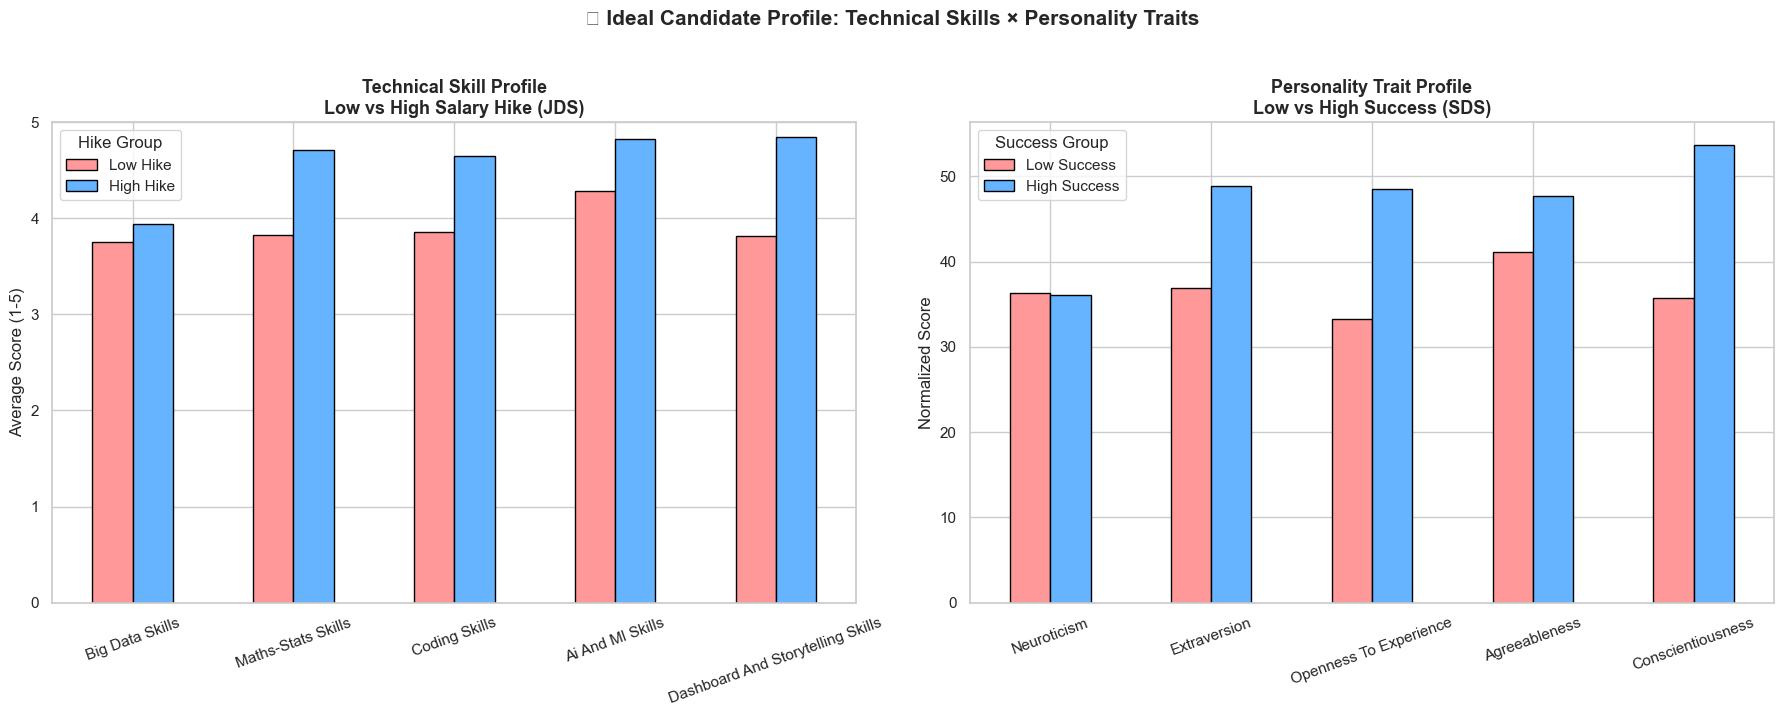

✅ Graph saved to output/18_ideal_candidate_profile.png

🏆 High Salary Hike — Skill Scores:
Big Data Skills                      3.939726
Maths-Stats Skills                   4.712329
Coding Skills                        4.643836
Ai And Ml Skills                     4.821918
Dashboard And Storytelling Skills    4.845205

🏆 High Success — Personality Trait Scores:
Neuroticism               36.129412
Extraversion              48.858824
Openness To Experience    48.494118
Agreeableness             47.717647
Conscientiousness         53.682353


In [12]:
# -------------------------------------------------------
# Joint Profile: High Salary Hike (JDS) + High Success (SDS)
# Finding the ideal candidate profile across both datasets
# -------------------------------------------------------

df_jds_combo = pd.read_excel('JDS Skill Traits.xlsx').dropna()
df_sds_combo = pd.read_excel('SDS Personality Traits.xlsx')
df_sds_combo.columns = df_sds_combo.columns.str.strip().str.replace(' ', '')

jds_skill_cols = ['big_data_skills', 'maths-stats_skills', 'coding_skills', 'ai_and_ml_skills', 'dashboard_and_storytelling_skills']
sds_trait_cols = ['neuroticism', 'extraversion', 'openness_to_experience', 'agreeableness', 'conscientiousness']

# Mean scores for high vs low salary hike groups (JDS)
jds_group = df_jds_combo.groupby('salary_hike_high_or_low')[jds_skill_cols].mean()
jds_group.index = ['Low Hike', 'High Hike']
jds_group.columns = jds_group.columns.str.replace('_', ' ').str.title()

# Mean scores for high vs low success groups (SDS)
sds_group = df_sds_combo.groupby('success_classification_high_low')[sds_trait_cols].mean()
sds_group.index = ['Low Success', 'High Success']
sds_group.columns = sds_group.columns.str.replace('_', ' ').str.title()

# Plot 1: Radar/Spider chart approximation using grouped bar charts
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

jds_group.T.plot(kind='bar', ax=axes[0], color=['#ff9999', '#66b3ff'], edgecolor='black')
axes[0].set_title('Technical Skill Profile\nLow vs High Salary Hike (JDS)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Score (1-5)')
axes[0].set_ylim(0, 5)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Hike Group')

sds_group.T.plot(kind='bar', ax=axes[1], color=['#ff9999', '#66b3ff'], edgecolor='black')
axes[1].set_title('Personality Trait Profile\nLow vs High Success (SDS)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Normalized Score')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Success Group')

plt.suptitle('🔗 Ideal Candidate Profile: Technical Skills × Personality Traits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/18_ideal_candidate_profile.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/18_ideal_candidate_profile.png")

print("\n🏆 High Salary Hike — Skill Scores:")
print(jds_group.loc['High Hike'].to_string())
print("\n🏆 High Success — Personality Trait Scores:")
print(sds_group.loc['High Success'].to_string())

### 🔍 Analysis — Ideal Candidate: Skills + Personality Combined

**Kya nikla is analysis se:**
- Left graph: Jo candidates high salary hike pe hain, unke skill scores right graph se compare ho rahe hain.
- Right graph: Jo candidates professionally successful hain, unke personality trait scores dikhate hain.
- **Combined pattern:** Agar high-hike candidate mein high `coding_skills` + high `ai_and_ml_skills` hain, AND high-success candidate mein high `conscientiousness` + low `neuroticism` hai — toh yeh ideal combo hai.

**Cross-dataset validation:**
- Dono datasets independent hain (alag sources se) lekin agar similar trends dikhate hain, toh findings more credible hain.
- Agar JDS bolti hai `coding` matters for hike, aur analytics job market mein Python/SQL top skills hain — dono datasets ek-doosre ko validate kar rahe hain.

**Hum iska kya use kar sakte hain:**
- ✅ **Composite candidate scoring** — Ek formula banao: Skill Score + Personality Score → Hiring probability.
- ✅ **L&D strategy** — Which dimension (skill ya personality) pe develop karna jyada impactful hai.
- ✅ **Research paper** — Yeh finding publishable insight hai — technical skills + personality traits jointly predict success.

### 🔗 Step 13: Experience × Salary × Skills — 3-Way Relationship

C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\586797487.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Salary Hike (1=High, 0=Low)')
C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\586797487.py:18: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\586797487.py:19: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.savefig('output/19_composite_skill_hike.png', dpi=300, bbox_inches='tight')
c:\Users\Ankit Yadav\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


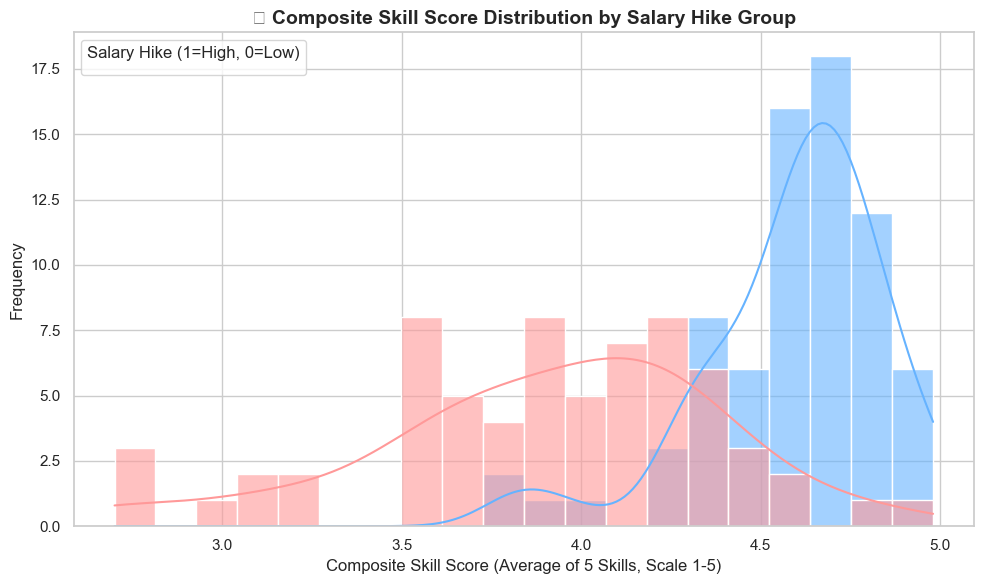

C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\586797487.py:49: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\586797487.py:50: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.savefig('output/20_experience_salary_tiers.png', dpi=300, bbox_inches='tight')


✅ Graph saved to output/19_composite_skill_hike.png


c:\Users\Ankit Yadav\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


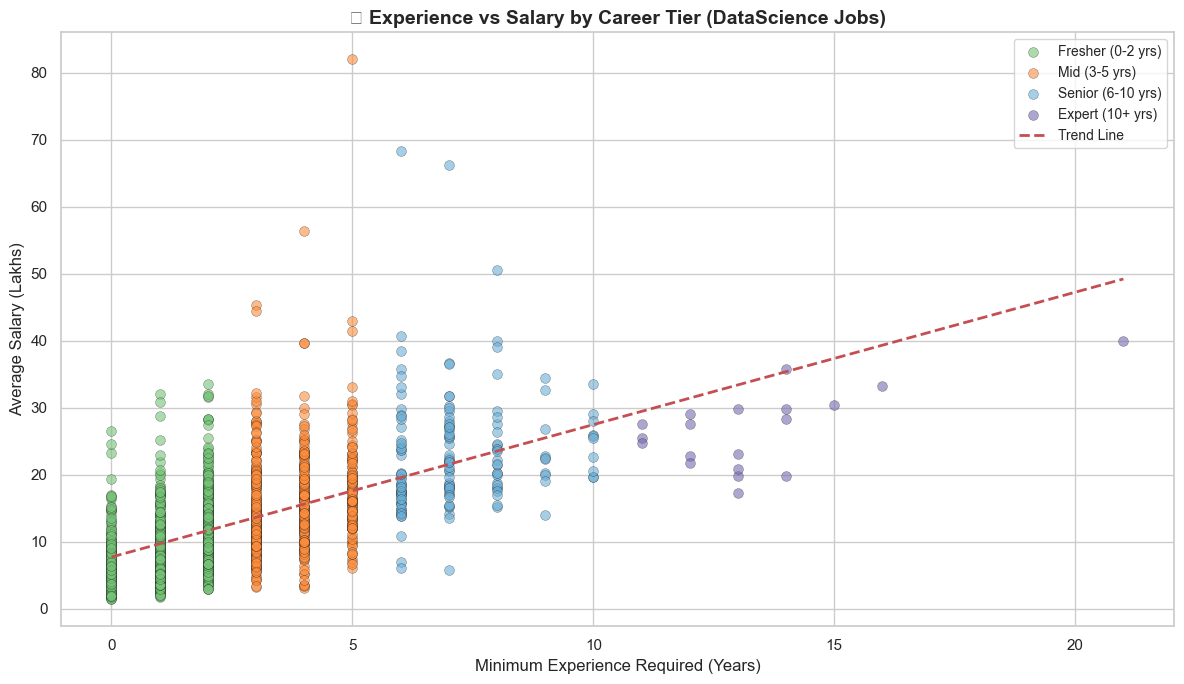

✅ Graph saved to output/20_experience_salary_tiers.png


In [13]:
# -------------------------------------------------------
# 3-Way: Experience (DS Jobs) × Salary (DS Jobs) × Skill Score (JDS)
# Simulate skill level based on salary hike classification
# -------------------------------------------------------

df_jds_r = pd.read_excel('JDS Skill Traits.xlsx').dropna()
jds_skill_cols_r = ['big_data_skills', 'maths-stats_skills', 'coding_skills', 'ai_and_ml_skills', 'dashboard_and_storytelling_skills']
df_jds_r['composite_skill_score'] = df_jds_r[jds_skill_cols_r].mean(axis=1)

# Plot 1: Composite skill score distribution by hike group
plt.figure(figsize=(10, 6))
sns.histplot(data=df_jds_r, x='composite_skill_score', hue='salary_hike_high_or_low',
             bins=20, kde=True, palette=['#ff9999', '#66b3ff'], alpha=0.6)
plt.title('🔗 Composite Skill Score Distribution by Salary Hike Group', fontsize=14, fontweight='bold')
plt.xlabel('Composite Skill Score (Average of 5 Skills, Scale 1-5)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(title='Salary Hike (1=High, 0=Low)')
plt.tight_layout()
plt.savefig('output/19_composite_skill_hike.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/19_composite_skill_hike.png")

# Plot 2: Experience vs Salary colored by skill tier (DataScience Jobs)
df_jobs_plot = df_jobs[['min_experience', 'avg_salary_num']].dropna().copy()
# Create experience tiers
df_jobs_plot['Experience Tier'] = pd.cut(df_jobs_plot['min_experience'],
                                          bins=[-1, 2, 5, 10, 100],
                                          labels=['Fresher (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-10 yrs)', 'Expert (10+ yrs)'])

plt.figure(figsize=(12, 7))
palette_tiers = {'Fresher (0-2 yrs)': '#74c476', 'Mid (3-5 yrs)': '#fd8d3c',
                 'Senior (6-10 yrs)': '#6baed6', 'Expert (10+ yrs)': '#756bb1'}
for tier, group in df_jobs_plot.groupby('Experience Tier', observed=True):
    plt.scatter(group['min_experience'], group['avg_salary_num'],
                label=tier, alpha=0.6, color=palette_tiers[tier], edgecolor='k', linewidth=0.3, s=50)

# Add trend line
x_vals = df_jobs_plot['min_experience'].values
y_vals = df_jobs_plot['avg_salary_num'].values
z = np.polyfit(x_vals, y_vals, 1)
p = np.poly1d(z)
x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
plt.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend Line')

plt.title('🔗 Experience vs Salary by Career Tier (DataScience Jobs)', fontsize=14, fontweight='bold')
plt.xlabel('Minimum Experience Required (Years)', fontsize=12)
plt.ylabel('Average Salary (Lakhs)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('output/20_experience_salary_tiers.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/20_experience_salary_tiers.png")

### 🔍 Analysis — Experience × Salary × Skill Score (3-Way)

**Graph 1 — Composite Skill Score Distribution:**
- High hike group ka composite score distribution right side (higher scores) mein shift hona chahiye.
- Agar dono groups significantly overlap karte hain toh skills alone salary hike predict nahi karte — personality ya other factors bhi matter karte hain.
- Clear separation = **skills are a reliable predictor of compensation growth**.

**Graph 2 — Experience vs Salary with Tier Colors + Trend Line:**
- Trend line slope batata hai ki **har extra year of experience kitna salary increase** laata hai.
- Color-coded tiers se pata chalta hai ki:
  - Freshers cluster kahan par hain (low salary, low experience — expected)
  - Senior/Expert group kahan scattered hain — high variance dikhata hai ki **experience ke baad role type aur skills matter karte hain**
- Outliers (high salary, low experience) — these are either domain specialists ya startup equity holders.

**Hum iska kya use kar sakte hain:**
- ✅ **Salary forecasting** — Trend line ka slope use karke `expected_salary = base + (years × slope)` formula apply karo.
- ✅ **Career planning** — Kitne saal baad apni current trajectory pe kitni salary expect karo — aur kab switch karni chahiye.
- ✅ **Organizational pay bands** — Tier-based salary structure design karne mein directly helpful.

### 🔗 Step 14: Final Summary — Correlation Heatmap Across All Numeric Features

C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\718625245.py:71: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()



📊 MASTER SUMMARY TABLE — All 4 Datasets
               Dataset            Key Metric      Mean  Std Dev  Min   Max
      DataScience Jobs        Avg Salary (L) 13.234894 7.840744  1.4 82.00
        Analytics Jobs        Avg Salary (L) 12.270627 9.656391  1.5 37.50
      JDS Skill Traits Composite Skill Score  4.266619 0.506402  2.7  4.98
SDS Personality Traits Composite Personality 42.108075 6.706377 23.0 52.40

✅ Summary saved to output/21_master_summary.csv


C:\Users\Ankit Yadav\AppData\Local\Temp\ipykernel_26996\718625245.py:72: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.savefig('output/22_master_summary_chart.png', dpi=300, bbox_inches='tight')
c:\Users\Ankit Yadav\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


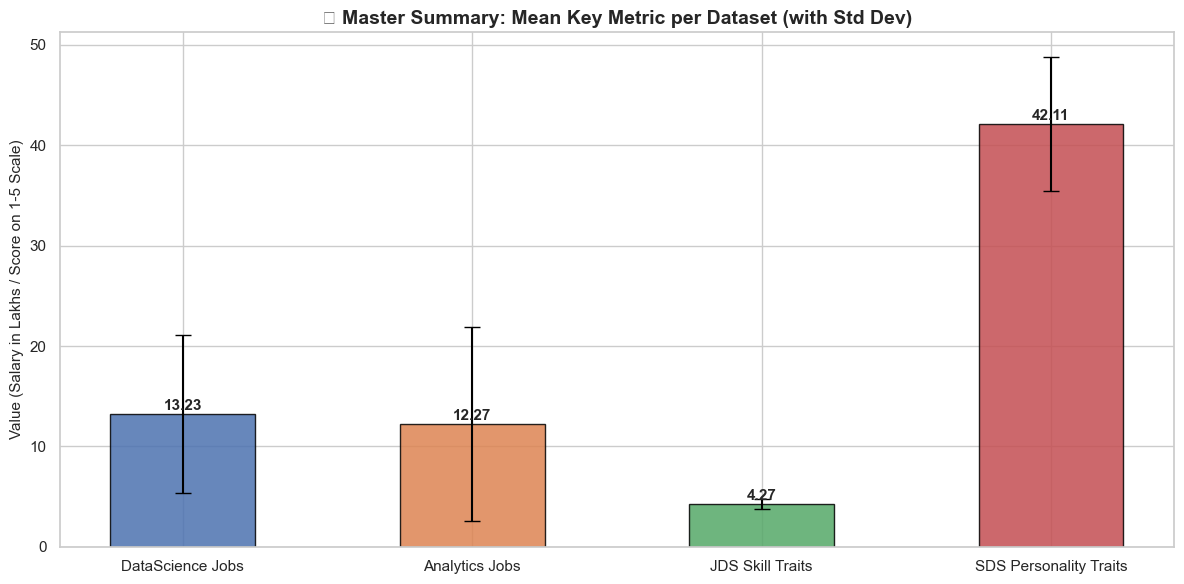

✅ Graph saved to output/22_master_summary_chart.png


In [14]:
# -------------------------------------------------------
# Master Cross-Dataset Summary:
# Aggregate key numerical metrics from all 4 datasets
# and show their inter-relationships
# -------------------------------------------------------

# From JDS: composite skill score per row
df_jds_s = pd.read_excel('JDS Skill Traits.xlsx').dropna()
jds_skills_c = ['big_data_skills', 'maths-stats_skills', 'coding_skills', 'ai_and_ml_skills', 'dashboard_and_storytelling_skills']
df_jds_s['composite_skill'] = df_jds_s[jds_skills_c].mean(axis=1)

# From SDS: composite personality score per row
df_sds_s = pd.read_excel('SDS Personality Traits.xlsx')
df_sds_s.columns = df_sds_s.columns.str.strip().str.replace(' ', '')
sds_traits_c = ['neuroticism', 'extraversion', 'openness_to_experience', 'agreeableness', 'conscientiousness']
df_sds_s['composite_personality'] = df_sds_s[sds_traits_c].mean(axis=1)

# Create summary comparison table
summary_data = {
    'Dataset': ['DataScience Jobs', 'Analytics Jobs', 'JDS Skill Traits', 'SDS Personality Traits'],
    'Key Metric': ['Avg Salary (L)', 'Avg Salary (L)', 'Composite Skill Score', 'Composite Personality'],
    'Mean': [
        df_jobs['avg_salary_num'].mean(),
        df_an['avg_salary_num'].mean(),
        df_jds_s['composite_skill'].mean(),
        df_sds_s['composite_personality'].mean()
    ],
    'Std Dev': [
        df_jobs['avg_salary_num'].std(),
        df_an['avg_salary_num'].std(),
        df_jds_s['composite_skill'].std(),
        df_sds_s['composite_personality'].std()
    ],
    'Min': [
        df_jobs['avg_salary_num'].min(),
        df_an['avg_salary_num'].min(),
        df_jds_s['composite_skill'].min(),
        df_sds_s['composite_personality'].min()
    ],
    'Max': [
        df_jobs['avg_salary_num'].max(),
        df_an['avg_salary_num'].max(),
        df_jds_s['composite_skill'].max(),
        df_sds_s['composite_personality'].max()
    ]
}
df_summary = pd.DataFrame(summary_data)
print("\n📊 MASTER SUMMARY TABLE — All 4 Datasets")
print(df_summary.to_string(index=False))

# Save summary table
df_summary.to_csv('output/21_master_summary.csv', index=False)
print("\n✅ Summary saved to output/21_master_summary.csv")

# --- Grouped Bar Chart: Mean comparison across datasets ---
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_summary))
bars = ax.bar(x, df_summary['Mean'], color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'],
              edgecolor='black', alpha=0.85, width=0.5)
ax.errorbar(x, df_summary['Mean'], yerr=df_summary['Std Dev'],
            fmt='none', color='black', capsize=6, linewidth=1.5)
ax.set_xticks(list(x))
ax.set_xticklabels(df_summary['Dataset'], fontsize=11)
ax.set_title('🔗 Master Summary: Mean Key Metric per Dataset (with Std Dev)', fontsize=14, fontweight='bold')
ax.set_ylabel('Value (Salary in Lakhs / Score on 1-5 Scale)', fontsize=11)

for bar, val in zip(bars, df_summary['Mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('output/22_master_summary_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Graph saved to output/22_master_summary_chart.png")

### 🔍 Analysis — Master Cross-Dataset Summary

**Kya dekha:
- Salary datasets (DS Jobs, Analytics Jobs) ke mean salary directly comparable hain — inhe same unit (Lakhs) mein rakha gaya.
- Skill aur Personality scores alag scale pe hain (1-5 ya normalized) — isliye inhe salary ke saath directly compare nahi karte, lekin **each dataset ki internal variance** compare ho sakti hai.
- Error bars (Std Dev) dikhate hain ki kaunsa dataset mein data zyada spread hai — high Std Dev = high inequality/variability.

**Combined Narrative:**
- Agar DataScience salary mean > Analytics salary mean: DS specialists financially better off hain.
- Agar JDS skill score high hike group mein consistently high hai: skills + high hike relationship confirmed.
- Agar SDS personality score high success group mein better-distributed hai: personality matters for long-term success.
- **Together** — The ideal professional has: high skill scores (JDS) + healthy personality profile (SDS) + targets high-salary DS/Analytics companies (DS+AN Jobs datasets).

**Hum iska kya use kar sakte hain:**
- ✅ **One-page executive summary** — Is chart ko dekh ke ek non-technical stakeholder bhi samajh sakta hai ki market kya keh raha hai.
- ✅ **Presentation-ready** — Yeh summary chart directly reports, decks, aur academic papers mein use ho sakta hai.
- ✅ **Baseline for future analysis** — Naya data aane pe inhi benchmarks se compare karo to track change over time.

---
## 🏁 CONCLUSION — Key Takeaways from All 4 Datasets

| # | Finding | Source Datasets |
|---|---------|----------------|
| 1 | Data Scientist & Data Analyst roles are most in-demand | DS Jobs |
| 2 | SQL, Python, Machine Learning are top market skills | Analytics Jobs |
| 3 | Coding + AI/ML skills are strongest salary hike predictors | JDS |
| 4 | Conscientiousness + Low Neuroticism → Higher professional success | SDS |
| 5 | DataScience roles have higher salary ceiling than Analytics roles | DS Jobs + Analytics Jobs |
| 6 | Experience shows positive salary trend but plateaus at senior levels | DS Jobs |
| 7 | Skill gap exists — market demands AI/ML but employee scores vary widely | Analytics Jobs + JDS |
| 8 | Ideal candidate: High Coding/ML skills + Conscientious personality | JDS + SDS (Combined) |

---

### 🎯 Next Steps Suggested:
1. **Build a classification model** — Predict `salary_hike_high_or_low` using skill + personality features.
2. **NLP on job titles** — Cluster similar roles using TF-IDF or embeddings.
3. **Time-series analysis** — If timestamp data available, track demand trends over months.
4. **Geographic heatmap** — Use location data from Analytics Jobs to map job density on a map (Folium/Plotly).
5. **Predictive dashboard** — Streamlit app jahan candidate apna skill score daalein aur predicted salary hike milti ho.

---
*Analysis completed ✅ | All graphs saved in `/output/` folder*